In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax
import torchcp
from data_config import get_config
import torch.optim as optim
from tqdm import tqdm


def platt_scale(logits, labels, max_iters=100, lr=0.01, epsilon=0.005):
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(logits),
                                             torch.from_numpy(labels).long()) 
    dataloader = torch.utils.data.DataLoader(dataset,
                                             batch_size=64,
                                             shuffle=True)

    nll_criterion = nn.CrossEntropyLoss().cuda()

    T = nn.Parameter(torch.Tensor([1.3]).cuda())
    optimizer = optim.SGD([T], lr=lr)
    for iter in tqdm(range(max_iters)):
        T_old = T.item()
        for x, targets in dataloader:
            optimizer.zero_grad()
            x = x.cuda()
            x.requires_grad = True
            out = x/T
            loss = nll_criterion(out, targets.long().cuda())
            loss.backward()
            optimizer.step()
        if abs(T_old - T.item()) < epsilon:
            break
    return T.item() 


In [2]:
config = get_config('imagenet1k_resnet50')  # cifar100_resnet56, imagenet1k_resnet50
config.par_calib = 0.5
config.num_calib = int(config.num_samples * config.par_calib)
config.alpha = 0.1

In [3]:
with open(config.file_name, 'rb') as file:
    data = pickle.load(file)

labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
    data["labels"], data["preds"], test_size=config.par_calib, random_state=42
)

t = platt_scale(scores_calib, labels_calib, max_iters=10, lr=0.01, epsilon=0.01)
print(t)
scores_calib = scores_calib / t
scores_eval = scores_eval / t

scores_calib = torch.from_numpy(scores_calib).type(torch.float64)
scores_eval = torch.from_numpy(scores_eval).type(torch.float64)

labels_calib = torch.from_numpy(labels_calib)
labels_eval = torch.from_numpy(labels_eval)

 10%|█         | 1/10 [00:01<00:09,  1.10s/it]

0.6126135587692261


In [4]:
import math
from torchcp.classification.predictors import SplitPredictor
from predictor import SplitPredictorVectorThreshold, APS, RAPS, SAPS
from torchcp.classification.utils.metrics import Metrics
metrics = Metrics()


conf_score = APS()
cal_scores_est = conf_score(scores_calib, scores_calib.argmax(1))
cal_scores_true = conf_score(scores_calib, labels_calib)
n = len(scores_calib)
normalizer = cal_scores_true.max() + 1e-10
residuales = (cal_scores_true - cal_scores_est) / (normalizer - cal_scores_est)

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qunatile_value = math.ceil((n + 1) * (1 - config.alpha)) / n
qhat = torch.quantile(residuales, qunatile_value, dim=0, interpolation='higher').to(residuales.device)

val_scores_est = conf_score(scores_eval, scores_eval.argmax(1))
val_scores_est_copy = val_scores_est
val_scores_true = conf_score(scores_eval, labels_eval)

val_scores_est = val_scores_est + qhat * (normalizer - val_scores_est)
print('Par of scores above 1: {:.2f}'.format(torch.sum(val_scores_est > 1) / len(val_scores_est)))
predictor = SplitPredictorVectorThreshold(conf_score)
prediction_sets = predictor.predict_with_logits(scores_eval, val_scores_est)
res_dict = {
    "Coverage_rate": metrics('coverage_rate')(prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(prediction_sets, labels_eval)
    }

print(res_dict)
print('qhat:', qhat)

Residuales: mean: 0.139 std: 0.300 min: 0.000 max: 1.000
Par of scores above 1: 0.00
{'Coverage_rate': 0.83284, 'Average_size': 9.98488}
qhat: tensor(0.7557, dtype=torch.float64)


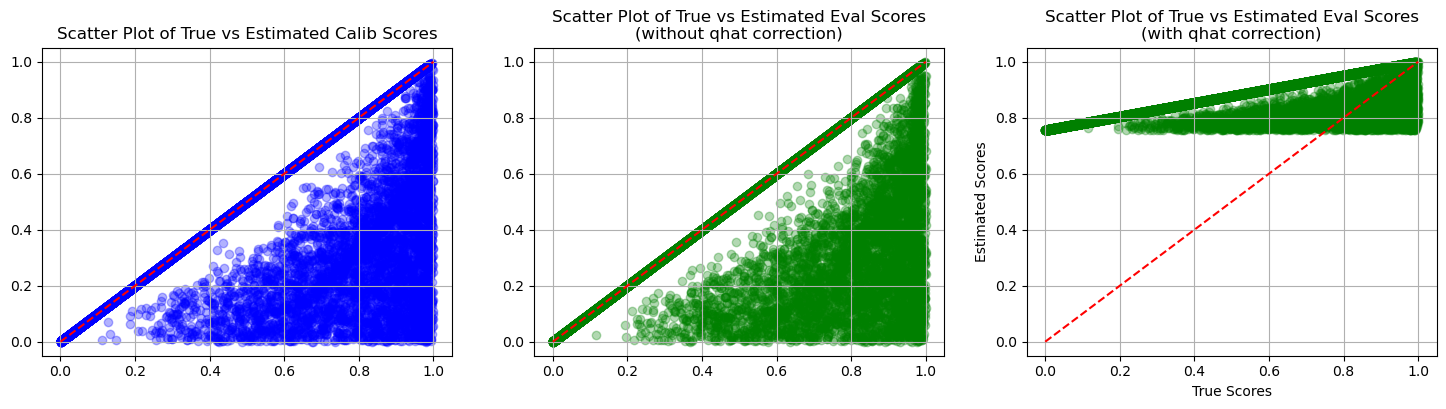

In [5]:
# debug #
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].scatter(cal_scores_true, cal_scores_est, color='blue', alpha=0.3)
ax[0].set_title('Scatter Plot of True vs Estimated Calib Scores')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].grid(True)

ax[1].scatter(val_scores_true, val_scores_est_copy, color='green', alpha=0.3)
ax[1].set_title('Scatter Plot of True vs Estimated Eval Scores\n(without qhat correction)')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].grid(True)

ax[2].scatter(val_scores_true, val_scores_est, color='green', alpha=0.3)
ax[2].set_title('Scatter Plot of True vs Estimated Eval Scores\n(with qhat correction)')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[2].plot([0, 1], [0, 1], 'r--')
ax[2].grid(True)
plt.show()

In [6]:
# baseline
baseline_predictor = SplitPredictor(conf_score)
baseline_predictor.calculate_threshold(scores_calib, labels_calib, config.alpha)
baseline_prediction_sets = baseline_predictor.predict_with_logits(scores_eval)
baseline_res_dict = {
    "Coverage_rate": metrics('coverage_rate')(baseline_prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(baseline_prediction_sets, labels_eval)}
print(baseline_res_dict)
print(baseline_predictor.q_hat.item())


{'Coverage_rate': 0.90008, 'Average_size': 14.7266}
0.9169562706951472
